In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import re

In [2]:
#hyperparameters
batch_size=64
lr=0.001
epochs=100


In [3]:
#emdeddings
OP_MAP = {
    '+': 'OP_ADD',
    '-': 'OP_SUB',
    '*': 'OP_MUL',
    '/': 'OP_DIV'
}

def tokenize_gep_string(gep_string):
    tokens = []
    for tok in gep_string.split(','):
        tok = tok.strip()
        if tok in OP_MAP:
            tokens.append((OP_MAP[tok], None))
        elif re.match(r'I\d+', tok):
            tokens.append((f'INV_{tok[1:]}', None))
        else:
            tokens.append(('CONST', float(tok)))
    return tokens

def build_vocab(tokenized_strings):
    vocab = {'PAD': 0}
    idx = 1

    for tokens in tokenized_strings:
        for token_type, _ in tokens:
            if token_type not in vocab:
                vocab[token_type] = idx
                idx += 1

    return vocab
def encode_tokens(tokens, vocab, max_len):
    token_ids = []
    num_vals = []
    for token_type, val in tokens:
        token_ids.append(vocab[token_type])
        num_vals.append(val / 100.0 if val is not None else 0.0)

    token_ids = token_ids[:max_len]
    num_vals = num_vals[:max_len]

    pad_len = max_len - len(token_ids)
    token_ids.extend([vocab['PAD']] * pad_len)
    num_vals.extend([0.0] * pad_len)

    return torch.tensor(token_ids), torch.tensor(num_vals, dtype=torch.float)
class GEPEmbedding(nn.Module):
    def __init__(self, vocab_size, max_len, embed_dim=64):
        super().__init__()
        self.embed_dim = embed_dim
        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.const_proj = nn.Linear(1, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)

    def forward(self, token_ids, num_vals):
        B, L = token_ids.shape
        tok_emb = self.token_embed(token_ids)
        num_emb = self.const_proj(num_vals.unsqueeze(-1))
        positions = torch.arange(L, device=token_ids.device)
        pos_emb = self.pos_embed(positions).unsqueeze(0)
        return tok_emb + num_emb + pos_emb  # (B, L, D)



In [4]:
class GEPDataset(Dataset):
    def __init__(self, strings, targets, vocab, max_len):
        self.strings = strings
        self.targets = targets
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.strings)

    def __getitem__(self, idx):
        tokens = tokenize_gep_string(self.strings[idx])
        token_ids, num_vals = encode_tokens(tokens, self.vocab, self.max_len)
        return token_ids, num_vals, torch.tensor(self.targets[idx], dtype=torch.float)
df=pd.read_csv("dataset.csv",)
df = df.drop("run_id", axis=1)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
x=list(df["string"])
y=df[["cost","p_initial_residual"]].values
y_mean = y.mean(axis=0)
y_std = y.std(axis=0)
y_norm = (y - y_mean) / (y_std + 1e-8)
tokenized_all = [tokenize_gep_string(s) for s in x]
vocab = build_vocab(tokenized_all)
MAX_LEN = 64
BATCH_SIZE = 64
dataset = GEPDataset(x, y_norm, vocab, MAX_LEN)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)


In [5]:
class NN(nn.Module):
    def __init__(self, dim_latent_space, output_dim, input_dim):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Dropout(0.1),
            nn.BatchNorm1d(input_dim),
            nn.ReLU()
        )
        self.l2 = nn.Sequential(
            nn.Linear(input_dim, input_dim *2),
            nn.Dropout(0.1),
            nn.BatchNorm1d(input_dim *2),
            nn.ReLU()
        )
        self.l3 = nn.Linear(input_dim *2, input_dim*4)
        self.l4 = nn.Sequential(
            nn.Linear(input_dim*4, input_dim*2),
            nn.Dropout(0.1),
            nn.BatchNorm1d(input_dim*2),
            nn.ReLU()
        )
        self.l5 = nn.Sequential(
            nn.Linear(input_dim *2, input_dim),
            nn.Dropout(0.1),
            nn.BatchNorm1d(input_dim),
            nn.ReLU()
        )
        self.l6 = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        l1 = self.l1(x)
        l2 = self.l2(l1)
        latent = self.l3(l2)
        l4 = self.l4(latent)
        l5 = self.l5(l4 )
        l6 = self.l6(l5)
        return l6
class FullModel(nn.Module):
    def __init__(self, vocab_size, max_len, embed_dim=64, dim_latent_space=32, output_dim=2):
        super().__init__()
        self.embedder = GEPEmbedding(vocab_size, max_len, embed_dim)
        # input_dim for MLP = embed_dim (after mean pooling)
        self.mlp = NN(dim_latent_space, output_dim, embed_dim)

    def forward(self, token_ids, num_vals):
        embeddings = self.embedder(token_ids, num_vals)    # (B, L, D)
        pooled = embeddings.mean(dim=1)                    # (B, D)
        return self.mlp(pooled)
        
        


In [6]:
device = torch.device("cpu")
model = FullModel(vocab_size=len(vocab), max_len=MAX_LEN).to(device)
optim=torch.optim.AdamW(model.parameters(),lr=5e-4)
loss_fn=nn.MSELoss()


In [7]:
loss_t=[]
loss_v=[]
for epoch in range(150):
    model.train()
    total_loss = 0
    for token_ids, num_vals, y_batch in train_loader:
        # Move tensors to CPU (optional, they're already on CPU)
        token_ids = token_ids.to(device)
        num_vals  = num_vals.to(device)
        y_batch   = y_batch.to(device)

        y_pred = model(token_ids, num_vals)
        loss = loss_fn(y_pred, y_batch)

        optim.zero_grad()
        loss.backward()
        optim.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} | Train Loss: {total_loss / len(train_loader):.4f}")
    loss_t.append(total_loss / len(train_loader))
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for token_ids, num_vals, y_batch in val_loader:
            token_ids = token_ids.to(device)
            num_vals  = num_vals.to(device)
            y_batch   = y_batch.to(device)

            y_pred = model(token_ids, num_vals)
            val_loss += loss_fn(y_pred, y_batch).item()

    print(f"Epoch {epoch} | Val Loss: {val_loss / len(val_loader):.4f}")
    loss_v.append(val_loss / len(val_loader))
    model.train()

Epoch 0 | Train Loss: 0.5382
Epoch 0 | Val Loss: 3.6755
Epoch 1 | Train Loss: 0.5021
Epoch 1 | Val Loss: 3.6744
Epoch 2 | Train Loss: 0.4902
Epoch 2 | Val Loss: 3.6787
Epoch 3 | Train Loss: 0.4863
Epoch 3 | Val Loss: 3.6805
Epoch 4 | Train Loss: 0.4895
Epoch 4 | Val Loss: 3.6830
Epoch 5 | Train Loss: 0.4798
Epoch 5 | Val Loss: 3.6724
Epoch 6 | Train Loss: 0.4805
Epoch 6 | Val Loss: 3.6744
Epoch 7 | Train Loss: 0.4760
Epoch 7 | Val Loss: 3.6819
Epoch 8 | Train Loss: 0.4704
Epoch 8 | Val Loss: 3.6805
Epoch 9 | Train Loss: 0.4678
Epoch 9 | Val Loss: 3.6779
Epoch 10 | Train Loss: 0.4744
Epoch 10 | Val Loss: 3.6761
Epoch 11 | Train Loss: 0.4697
Epoch 11 | Val Loss: 3.6773
Epoch 12 | Train Loss: 0.4701
Epoch 12 | Val Loss: 3.6767
Epoch 13 | Train Loss: 0.4724
Epoch 13 | Val Loss: 3.6766
Epoch 14 | Train Loss: 0.4676
Epoch 14 | Val Loss: 3.6802
Epoch 15 | Train Loss: 0.4670
Epoch 15 | Val Loss: 3.6762
Epoch 16 | Train Loss: 0.4675
Epoch 16 | Val Loss: 3.6860
Epoch 17 | Train Loss: 0.4708
Epoc

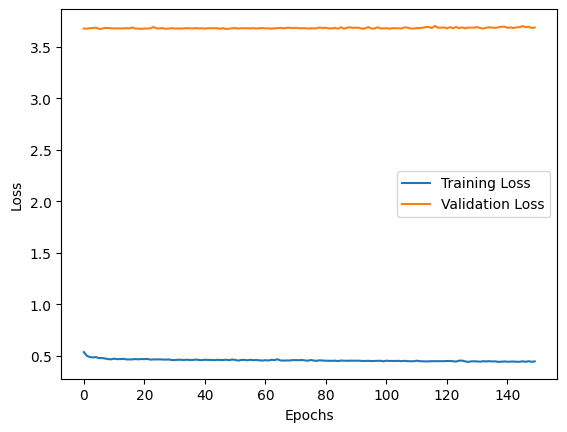

In [8]:
import matplotlib.pyplot as plt
plt.plot(loss_t, label="Training Loss")
plt.plot(loss_v, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

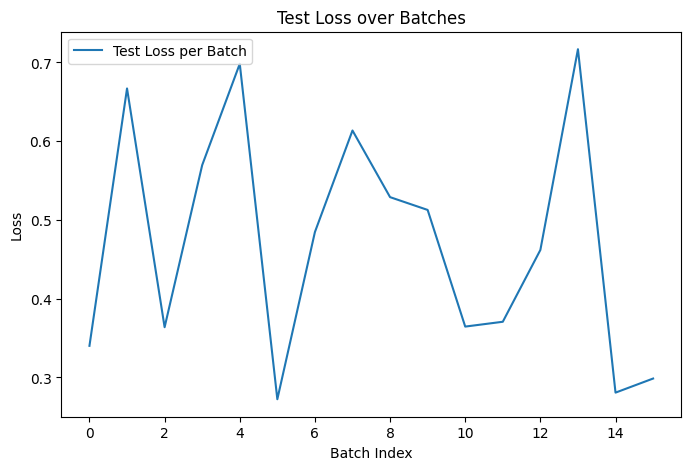

In [9]:
loss_t = []

model.eval()
with torch.no_grad():
    for token_ids, num_vals, y_batch in test_loader:
        token_ids = token_ids.to(device)
        num_vals  = num_vals.to(device)
        y_batch   = y_batch.to(device)

        y_pred = model(token_ids, num_vals)
        loss = loss_fn(y_pred, y_batch)
        loss_t.append(loss.item())  # append per-batch loss

# Plotting
plt.figure(figsize=(8,5))
plt.plot(loss_t, label="Test Loss per Batch")
plt.xlabel("Batch Index")
plt.ylabel("Loss")
plt.title("Test Loss over Batches")
plt.legend()
plt.show()


In [10]:
from torch.utils.data import DataLoader, Subset

# Take first 5 samples safely
dataset_example = Subset(dataset, range(5))

y_pred_examples = []
y_real = []

model.eval()
with torch.no_grad():
    for token_ids, num_vals, y_batch in DataLoader(dataset_example, batch_size=5):
        token_ids = token_ids.to(device)
        num_vals  = num_vals.to(device)
        y_batch   = y_batch.to(device)

        # Forward pass
        y_pred = model(token_ids, num_vals)

        # Denormalize
        y_pred = y_pred * (y_std + 1e-8) + y_mean
        y_batch = y_batch * (y_std + 1e-8) + y_mean

        y_pred_examples.append(y_pred.cpu())
        y_real.append(y_batch.cpu())

# Print nicely
print("Predicted vs Real:")
for yp, yr in zip(y_pred_examples[0], y_real[0]):
    print(f"Predicted: {yp.numpy()} | Real: {yr.numpy()}")


Predicted vs Real:
Predicted: [1.77077121e+76 6.81167790e-02] | Real: [-3.24938903e+68  3.77327006e-01]
Predicted: [-1.72847788e+76  6.14762028e-02] | Real: [-3.24938903e+68  3.10638005e-02]
Predicted: [-5.28939872e+75  1.30642866e-01] | Real: [-3.24938903e+68  5.55523988e-01]
Predicted: [9.14189585e+75 2.46962965e-01] | Real: [-3.24938903e+68  1.68168012e-02]
Predicted: [3.91242497e+75 1.06888633e-01] | Real: [-3.24938903e+68  1.24844000e-01]


C:\Users\asus\AppData\Local\Temp\ipykernel_31048\3000641300.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = y_pred * (y_std + 1e-8) + y_mean
C:\Users\asus\AppData\Local\Temp\ipykernel_31048\3000641300.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_batch = y_batch * (y_std + 1e-8) + y_mean


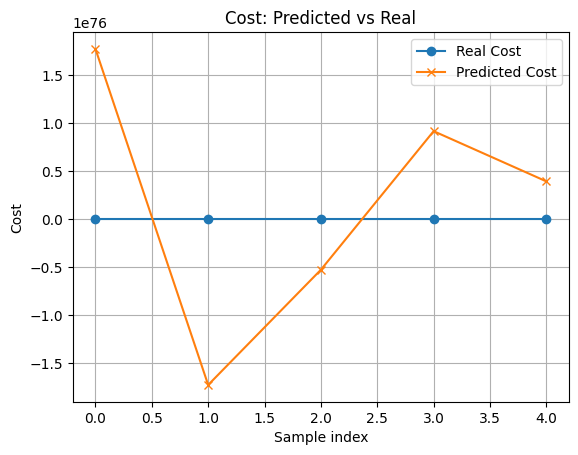

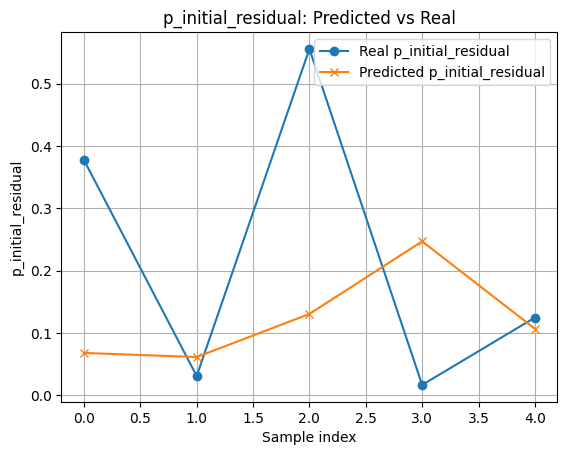

In [11]:
y_pred_all = torch.cat(y_pred_examples, dim=0).numpy()
y_real_all = torch.cat(y_real, dim=0).numpy()

# Split into cost and p
pred_cost = y_pred_all[:, 0]
pred_p    = y_pred_all[:, 1]

real_cost = y_real_all[:, 0]
real_p    = y_real_all[:, 1]
plt.figure()
plt.plot(real_cost, label="Real Cost", marker="o")
plt.plot(pred_cost, label="Predicted Cost", marker="x")
plt.xlabel("Sample index")
plt.ylabel("Cost")
plt.title("Cost: Predicted vs Real")
plt.legend()
plt.grid(True)
plt.show()
plt.figure()
plt.plot(real_p, label="Real p_initial_residual", marker="o")
plt.plot(pred_p, label="Predicted p_initial_residual", marker="x")
plt.xlabel("Sample index")
plt.ylabel("p_initial_residual")
plt.title("p_initial_residual: Predicted vs Real")
plt.legend()
plt.grid(True)
plt.show()